In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Để lưu scaler
import os 
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Cấu hình hiển thị
sns.set(style='whitegrid')
print("✅ Đã nhập khẩu thư viện thành công!")

✅ Đã nhập khẩu thư viện thành công!


In [7]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


In [8]:
# 1. Đọc dữ liệu (Thay tên file của bạn vào đây)
# df = pd.read_csv('du_lieu_cua_ban.csv') 
# Giả sử df đã có sẵn trong bộ nhớ, dòng này để convert time
df['time'] = pd.to_datetime(df['time'])

# 2. Xử lý Outlier (Giá trị ngoại lai)
# PM2.5 không thể > 800 (theo thang đo AQI chuẩn)
df['PM2.5'] = df['PM2.5'].mask(df['PM2.5'] > 800, np.nan)

# Nếu có cột CO, xử lý tương tự
if 'CO' in df.columns:
    df['CO'] = df['CO'].mask(df['CO'] > 5000, np.nan)

# 3. Điền dữ liệu khuyết (Interpolation)
# Dùng phương pháp nội suy tuyến tính để lấp đầy các khoảng trống do sensor lỗi
df = df.interpolate(method='linear', limit_direction='both')

print("✅ Đã làm sạch dữ liệu!")
print(f"Kích thước dữ liệu: {df.shape}")

✅ Đã làm sạch dữ liệu!
Kích thước dữ liệu: (26880, 14)


In [9]:
# Trích xuất giờ và tháng
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek

# Cyclical Encoding (Mã hóa chu kỳ cho giờ)
# Giúp model hiểu 23h rất gần với 0h
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclical Encoding cho tháng
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Chọn các Features quan trọng nhất để đưa vào Model
# Bỏ cột 'time' (vì đã mã hóa) và 'PM2.5' (sẽ xử lý riêng)
feature_cols = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos'] 
# Nếu có thêm Temp, Humid, CO thì thêm tên cột vào list trên

print("✅ Đã tạo xong các đặc trưng thời gian (Feature Engineering)!")

✅ Đã tạo xong các đặc trưng thời gian (Feature Engineering)!


In [10]:
# 1. Scaler cho INPUT (Các biến đầu vào trừ PM2.5 mục tiêu)
# Thêm PM2.5 vào Input để model học từ quá khứ
input_cols = ['PM2.5'] + feature_cols 

scaler_X = RobustScaler() # RobustScaler chịu nhiễu tốt hơn MinMaxScaler
df_scaled_input = scaler_X.fit_transform(df[input_cols])

# 2. Scaler cho OUTPUT (Chỉ riêng cột PM2.5 cần dự báo)
# Dùng MinMaxScaler [0,1] cho Output để Model dễ hội tụ
scaler_y = MinMaxScaler(feature_range=(0, 1))
target_col = 'PM2.5'
df_scaled_target = scaler_y.fit_transform(df[[target_col]])

print("✅ Đã chuẩn hóa dữ liệu (Scaling) thành công!")
print(f"Input shape: {df_scaled_input.shape}")
print(f"Target shape: {df_scaled_target.shape}")

✅ Đã chuẩn hóa dữ liệu (Scaling) thành công!
Input shape: (26880, 5)
Target shape: (26880, 1)


In [11]:
def create_dataset(dataset_X, target_y, n_past=24, n_future=24):
    """
    dataset_X: Dữ liệu đầu vào đã scale
    target_y:  Dữ liệu mục tiêu đã scale (riêng biệt)
    n_past:    Số giờ nhìn lại quá khứ
    n_future:  Số giờ dự báo tương lai
    """
    X, y = [], []
    for i in range(n_past, len(dataset_X) - n_future + 1):
        # Lấy n_past giờ quá khứ của TOÀN BỘ features
        X.append(dataset_X[i - n_past : i, :]) 
        # Lấy n_future giờ tương lai của CHỈ cột PM2.5
        y.append(target_y[i : i + n_future, 0]) 
        
    return np.array(X), np.array(y)

print("✅ Đã khai báo hàm Sliding Window!")

✅ Đã khai báo hàm Sliding Window!


In [12]:
# Tham số bài toán
N_PAST = 24   # Nhìn lại 24h
N_FUTURE = 24 # Dự báo 24h tới

# 1. Tạo dữ liệu chuỗi
X, y = create_dataset(df_scaled_input, df_scaled_target, N_PAST, N_FUTURE)

# 2. Chia tập dữ liệu (Splitting)
# Tỷ lệ: 70% Train - 15% Val - 15% Test
# Quan trọng: shuffle=True để trộn đều dữ liệu mưa/nắng/ngày/đêm
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

print("✅ Đã chia và trộn dữ liệu thành công!")
print(f"   X_train: {X_train.shape} (Input: 24h quá khứ)")
print(f"   y_train: {y_train.shape} (Output: 24h tương lai)")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")

✅ Đã chia và trộn dữ liệu thành công!
   X_train: (18783, 24, 5) (Input: 24h quá khứ)
   y_train: (18783, 24) (Output: 24h tương lai)
   X_val:   (4025, 24, 5)
   X_test:  (4025, 24, 5)


In [13]:
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Layer GRU: 64 units
# GRU hoạt động hiệu quả hơn LSTM trên các dataset cỡ vừa và nhỏ
model.add(GRU(units=64, return_sequences=False)) 
model.add(Dropout(0.2)) # Tắt 20% nơ-ron ngẫu nhiên để chống học vẹt

# Output Layer
# 24 nơ-ron tương ứng với 24 giờ dự báo
model.add(Dense(units=24)) 

# Compile Model
# Loss='mse' giúp phạt nặng các sai số lớn
# Optimizer Adam với learning rate chuẩn
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 64)                13632     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 24)                1560      
                                                                 
Total params: 15,192
Trainable params: 15,192
Non-trainable params: 0
_________________________________________________________________


In [14]:
# Callbacks
callbacks = [
    # Nếu Val_Loss không giảm sau 5 epochs -> Giảm learning rate đi 5 lần
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5, verbose=1),
    
    # Nếu Val_Loss không giảm sau 15 epochs -> Dừng train để tiết kiệm thời gian
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

print("🚀 Bắt đầu quá trình Huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=100,             # Số vòng lặp tối đa
    batch_size=32,          # Học mỗi lần 32 mẫu
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print("🎉 Huấn luyện hoàn tất!")

🚀 Bắt đầu quá trình Huấn luyện...
Epoch 1/100
587/587 [==============================] - 7s 6ms/step - loss: 0.0137 - val_loss: 0.0082 - lr: 0.0010
Epoch 2/100
587/587 [==============================] - 3s 5ms/step - loss: 0.0084 - val_loss: 0.0077 - lr: 0.0010
Epoch 3/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0079 - val_loss: 0.0076 - lr: 0.0010
Epoch 4/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0077 - val_loss: 0.0076 - lr: 0.0010
Epoch 5/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0075 - val_loss: 0.0074 - lr: 0.0010
Epoch 6/100
587/587 [==============================] - 4s 6ms/step - loss: 0.0074 - val_loss: 0.0073 - lr: 0.0010
Epoch 7/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0072 - val_loss: 0.0071 - lr: 0.0010
Epoch 8/100
587/587 [==============================] - 4s 7ms/step - loss: 0.0071 - val_loss: 0.0070 - lr: 0.0010
Epoch 9/100
587/587 [==============================] -

In [15]:
print("--- ĐÁNH GIÁ TRÊN TẬP TEST ---")

# 1. Dự báo trên tập Test
y_pred_scaled = model.predict(X_test)

# 2. Khôi phục giá trị thực (Inverse Scaling)
# Vì đã dùng scaler_y riêng nên việc này rất đơn giản
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Đảm bảo không có giá trị âm (PM2.5 >= 0)
y_pred = np.maximum(y_pred, 0)
y_true = np.maximum(y_true, 0)

# 3. Tính toán sai số trung bình cho cả 24 giờ
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred) # R2 score (Càng gần 1 càng tốt)

print(f"\n📊 KẾT QUẢ CUỐI CÙNG:")
print(f"   RMSE (Sai số toàn phương): {rmse:.2f} µg/m³")
print(f"   MAE  (Sai số tuyệt đối):   {mae:.2f} µg/m³")
print(f"   R2 Score (Độ phù hợp):     {r2:.4f}")

--- ĐÁNH GIÁ TRÊN TẬP TEST ---
126/126 [==============================] - 1s 3ms/step

📊 KẾT QUẢ CUỐI CÙNG:
   RMSE (Sai số toàn phương): 9.36 µg/m³
   MAE  (Sai số tuyệt đối):   6.49 µg/m³
   R2 Score (Độ phù hợp):     0.5438


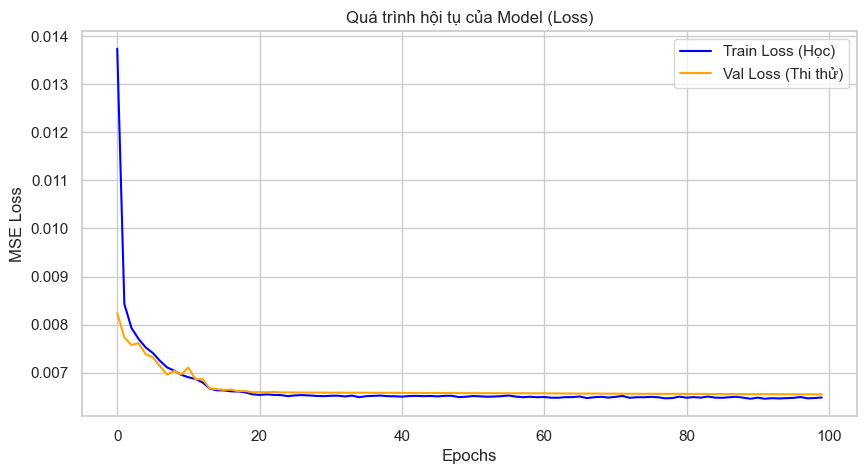

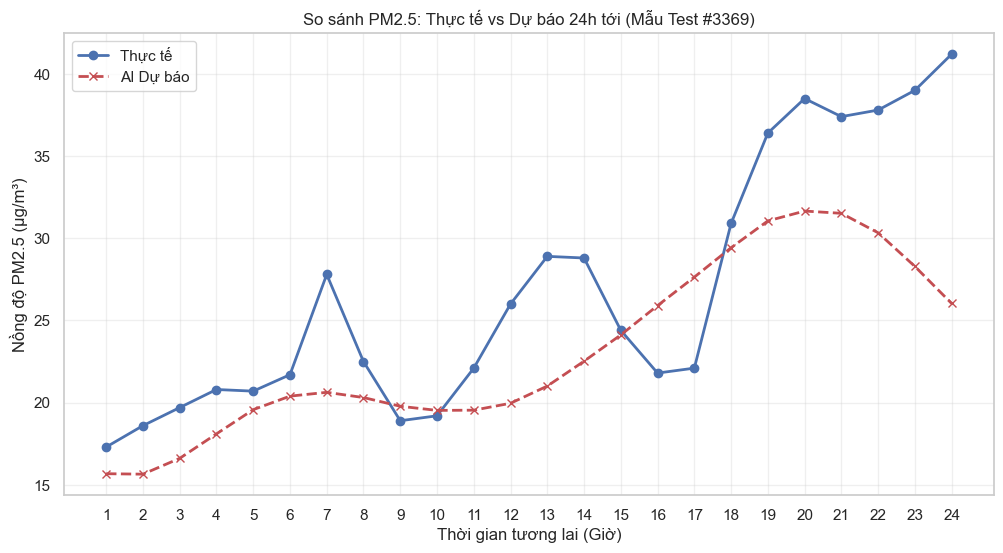

In [16]:
# 1. Biểu đồ Loss (Học vs Thi)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (Học)', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss (Thi thử)', color='orange')
plt.title('Quá trình hội tụ của Model (Loss)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# 2. Biểu đồ so sánh ngẫu nhiên 1 mẫu trong tập Test
import random
idx = random.randint(0, len(y_test) - 1)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), y_true[idx], 'b-o', label='Thực tế', linewidth=2)
plt.plot(range(1, 25), y_pred[idx], 'r--x', label='AI Dự báo', linewidth=2)
plt.title(f'So sánh PM2.5: Thực tế vs Dự báo 24h tới (Mẫu Test #{idx})')
plt.xlabel('Thời gian tương lai (Giờ)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.xticks(range(1, 25))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Lưu Model Deep Learning
model.save('aqi_forecasting_gru_24h_vfinal.keras')
print("✅ Đã lưu file Model: aqi_forecasting_gru_24h_vfinal.keras")

# Lưu Scaler (Rất quan trọng để Inverse dữ liệu mới)
joblib.dump(scaler_X, 'scaler_X_final.pkl')
joblib.dump(scaler_y, 'scaler_y_final.pkl')
print("✅ Đã lưu file Scaler: scaler_X_final.pkl & scaler_y_final.pkl")

print("\n🎉 CHÚC MỪNG! BẠN ĐÃ HOÀN THÀNH DỰ ÁN DỰ BÁO KHÔNG KHÍ!")

✅ Đã lưu file Model: aqi_forecasting_gru_24h_vfinal.keras
✅ Đã lưu file Scaler: scaler_X_final.pkl & scaler_y_final.pkl

🎉 CHÚC MỪNG! BẠN ĐÃ HOÀN THÀNH DỰ ÁN DỰ BÁO KHÔNG KHÍ!
